In [6]:
!pip install shapely

In [7]:
import os
import json
from PIL import Image  # 🖼️ Image processing for dimensions
from shapely.geometry import Polygon  # 🧮 Geometry operations for polygons

def yolo_polygon_to_coco(images_dir, labels_dir, class_names, output_json):
    """
    🚀 Converts YOLO polygon annotations to COCO segmentation format with 0-based IDs.

    Args:
        images_dir (str): 📁 Path to folder containing images
        labels_dir (str): 📄 Path to YOLO .txt files (polygon labels)
        class_names (list): 🧾 List of class names (index matches YOLO IDs)
        output_json (str): 💾 Output path for COCO JSON file
    """
    
    # 🧱 COCO JSON structure template
    coco = {
        "images": [],
        "annotations": [],
        # 🔢 Categories with 0-based indexing (YOLO class IDs match this)
        "categories": [{"id": i, "name": c} for i, c in enumerate(class_names)]
    }
    ann_id = 0  # 🧾 Global annotation counter (0-based)
    
    # 🖼️ Process each image
    for img_id, img_file in enumerate(os.listdir(images_dir)):
        # ✅ Skip non-image files
        if not img_file.lower().endswith((".jpg", ".png")):
            continue
        
        # 📏 Get image dimensions
        img_path = os.path.join(images_dir, img_file)
        w, h = Image.open(img_path).size
        
        # 📦 Add image metadata to COCO
        coco["images"].append({
            "id": img_id,  # 🆔 0-based image ID
            "file_name": img_file,
            "width": w,
            "height": h
        })
        
        # 📄 Find corresponding label file
        label_path = os.path.join(labels_dir, os.path.splitext(img_file)[0] + ".txt")
        if not os.path.exists(label_path):
            continue  # 🚫 Skip if no labels
        
        # 📝 Process each annotation line
        with open(label_path, "r") as f:
            for line in f:
                vals = list(map(float, line.strip().split()))
                cls_id = int(vals[0])  # 🧾 0-based class ID from first value
                
                # 🚫 Skip invalid polygons (need at least 3 points = 6 coords)
                if len(vals) < 4:
                    continue
                
                # 🔁 Denormalize coordinates (convert 0-1 to pixel values)
                points_norm = vals[1:]
                points_pix = []
                for i in range(0, len(points_norm), 2):
                    x = points_norm[i] * w
                    y = points_norm[i+1] * h
                    points_pix.extend([x, y])
                
                # 🔄 Fix invalid polygons using buffer(0)
                poly = Polygon([(points_pix[i], points_pix[i+1]) 
                               for i in range(0, len(points_pix), 2)])
                if not poly.is_valid:
                    poly = poly.buffer(0)
                
                # 📐 Calculate bounding box and area
                x_min, y_min, x_max, y_max = poly.bounds
                bbox = [x_min, y_min, x_max - x_min, y_max - y_min]
                
                # 📦 Add annotation to COCO
                coco["annotations"].append({
                    "id": ann_id,  # 🆔 0-based annotation ID
                    "image_id": img_id,
                    "category_id": cls_id,
                    "segmentation": [points_pix],  # 🌐 Polygon coordinates
                    "area": poly.area,  # 📏 Calculated area
                    "bbox": bbox,  # 📐 Bounding box [x, y, w, h]
                    "iscrowd": 0  # 🧍 Not a crowd annotation
                })
                ann_id += 1  # 🔢 Increment annotation counter

    # 💾 Save final COCO JSON
    with open(output_json, "w") as f:
        json.dump(coco, f, indent=2)
    
    print(f"✅ Conversion complete! 🎉 COCO JSON saved at: {output_json}")
    print(f"📊 Total images processed: {len(coco['images'])}")
    print(f"📌 Total annotations created: {len(coco['annotations'])}")


In [8]:
# 📁 Define dataset paths
train_path = '/kaggle/input/bone-fracture-detection-computer-vision-project/BoneFractureYolo8/train/'  # 🚂 Training dataset directory
test_path = '/kaggle/input/bone-fracture-detection-computer-vision-project/BoneFractureYolo8/test/'    # 🧪 Testing dataset directory  
val_path = '/kaggle/input/bone-fracture-detection-computer-vision-project/BoneFractureYolo8/valid/'    # ✅ Validation dataset directory

# 🏷️ Class names for bone fracture detection (must match YOLO class IDs)
class_names = [
    'elbow positive',        # 🤚 Elbow fracture positive cases
    'fingers positive',      # 👆 Fingers fracture positive cases
    'forearm fracture',      # 💪 Forearm fracture detection
    'humerus fracture',      # 🦴 Humerus bone fracture
    'humerus',               # 🦴 Humerus bone (normal/negative cases)
    'shoulder fracture',     # 🏋️ Shoulder joint fracture
    'wrist positive'         # ✋ Wrist fracture positive cases
]

# 💾 Output directory for converted files
output_path = '/kaggle/working/'  # 📂 Kaggle working directory for output files


In [9]:
# 🚀 Convert TRAINING dataset from YOLO polygon to COCO format
yolo_polygon_to_coco(
    images_dir=train_path+"images",           # 📂 Training images folder
    labels_dir=train_path+"labels",           # 📄 Training YOLO polygon labels folder
    class_names=class_names,                  # 🏷️ Class names list (7 bone fracture classes)
    output_json=output_path+"annotations_train.json"      # 💾 Output COCO JSON for training
)

# 🧪 Convert TESTING dataset from YOLO polygon to COCO format
yolo_polygon_to_coco(
    images_dir=test_path+"images",           # 📂 Testing images folder
    labels_dir=test_path+"labels",           # 📄 Testing YOLO polygon labels folder
    class_names=class_names,                 # 🏷️ Same class names for consistency
    output_json=output_path+"annotations_test.json"      # 💾 Output COCO JSON for testing
)

# ✅ Convert VALIDATION dataset from YOLO polygon to COCO format
yolo_polygon_to_coco(
    images_dir=val_path+"images",           # 📂 Validation images folder
    labels_dir=val_path+"labels",           # 📄 Validation YOLO polygon labels folder
    class_names=class_names,                # 🏷️ Class names (maintaining same mapping)
    output_json=output_path+"annotations_val.json"      # 💾 Output COCO JSON for validation
)

# 🎯 All three datasets will now be converted to COCO format!
# 📊 This creates a complete dataset split for machine learning training
# 🔄 Maintaining consistent class IDs across all splits is crucial for model training


✅ Conversion complete! 🎉 COCO JSON saved at: /kaggle/working/annotations_train.json
📊 Total images processed: 3631
📌 Total annotations created: 2088
✅ Conversion complete! 🎉 COCO JSON saved at: /kaggle/working/annotations_test.json
📊 Total images processed: 169
📌 Total annotations created: 96
✅ Conversion complete! 🎉 COCO JSON saved at: /kaggle/working/annotations_val.json
📊 Total images processed: 348
📌 Total annotations created: 204


In [10]:
import json

# 📍 Path to the COCO JSON file created by our conversion function
json_path = output_path+"annotations_train.json"  # 🚂 Training annotations file

# 📂 Open and load the COCO JSON data
with open(json_path, "r") as f:
    coco_data = json.load(f)  # 📖 Read and parse JSON content into Python dictionary

# 🎯 Display complete or partial data structure
# Example: Show top-level keys of the COCO dataset
print("🔑 Top-level keys in COCO data:")
print(coco_data.keys())  # 📋 Should show: dict_keys(['images', 'annotations', 'categories'])
print("\n" + "="*50 + "\n")

# Example: Display metadata of the first image
print("🖼️ First image metadata:")
print(json.dumps(coco_data["images"][0], indent=2))  # 📊 Pretty-print first image info
print("\n" + "="*50 + "\n")

# Example: Display details of the first annotation
print("📌 First annotation details:")
print(json.dumps(coco_data["annotations"][0], indent=2))  # 📝 Pretty-print first annotation
print("\n" + "="*50 + "\n")

# Example: Display all categories/classes
print("🏷️ All categories/classes:")
print(json.dumps(coco_data["categories"], indent=2))  # 🧾 Pretty-print all categories
print("\n" + "="*50 + "\n")

# 📊 Bonus: Show dataset statistics
print("📈 Dataset Statistics:")
print(f"Total images: {len(coco_data['images'])} 📸")
print(f"Total annotations: {len(coco_data['annotations'])} 📍")
print(f"Total categories: {len(coco_data['categories'])} 🏷️")


🔑 Top-level keys in COCO data:
dict_keys(['images', 'annotations', 'categories'])


🖼️ First image metadata:
{
  "id": 0,
  "file_name": "image1_1872_png.rf.7c06f57af1282f7e5cbbf99df577f5ab.jpg",
  "width": 512,
  "height": 379
}


📌 First annotation details:
{
  "id": 0,
  "image_id": 0,
  "category_id": 0,
  "segmentation": [
    [
      221.69229360727164,
      115.53846212533803,
      316.2206898641124,
      112.51608539655135,
      306.9914530178567,
      212.85290013225304,
      230.08114596572545,
      197.46381739727195
    ]
  ],
  "area": 7814.295719070318,
  "bbox": [
    221.69229360727164,
    112.51608539655135,
    94.52839625684075,
    100.3368147357017
  ],
  "iscrowd": 0
}


🏷️ All categories/classes:
[
  {
    "id": 0,
    "name": "elbow positive"
  },
  {
    "id": 1,
    "name": "fingers positive"
  },
  {
    "id": 2,
    "name": "forearm fracture"
  },
  {
    "id": 3,
    "name": "humerus fracture"
  },
  {
    "id": 4,
    "name": "humerus"
  },
  {
   

In [11]:
import torch  # 🧠 PyTorch - Deep learning framework
import torchvision  # 👁️ TorchVision - Computer vision library
from torchvision.models.detection import FasterRCNN  # 🚀 Faster R-CNN object detection model
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor  # 🔮 Custom classifier head for Faster R-CNN
from torch.utils.data import DataLoader, Dataset  # 📦 Data handling utilities
from PIL import Image  # 🖼️ Image processing library
import os  # 📁 Operating system interface
import numpy as np  # 🔢 Numerical computing library


In [12]:
class COCODataset(torch.utils.data.Dataset):
    def __init__(self, img_dir, annotation_file, transforms=None):
        self.img_dir = img_dir  # 📁 Directory containing images
        self.transforms = transforms  # 🔄 Image transformations/augmentations
        
        # 📖 Load COCO annotation JSON file
        with open(annotation_file, "r") as f:
            coco_data = json.load(f)  # 📋 Parse JSON data
        
        self.images = coco_data["images"]  # 🖼️ List of image metadata
        self.annotations = coco_data["annotations"]  # 📍 List of all annotations
        
        # 🗂️ Create mapping from image ID to its annotations
        self.img2annots = {img["id"]: [] for img in self.images}  # 📊 Empty list for each image
        for ann in self.annotations:
            self.img2annots[ann["image_id"]].append(ann)  # ➕ Add annotation to corresponding image

    def __getitem__(self, idx):
        # 📸 Get image information and load the image
        img_info = self.images[idx]  # 📋 Metadata for this image
        img_path = os.path.join(self.img_dir, img_info["file_name"])  # 🗺️ Full image path
        img = Image.open(img_path).convert("RGB")  # 🖼️ Load as RGB (3 channels)
        width, height = img.size  # 📏 Original image dimensions
        
        # 📍 Get all annotations for this image
        annots = self.img2annots[img_info["id"]]
        boxes = []  # 📦 List for bounding boxes
        labels = []  # 🏷️ List for class labels
        
        # 🔍 Process each annotation
        for ann in annots:
            x, y, w, h = ann["bbox"]  # 📐 Extract COCO bbox format [x, y, width, height]

            # 🚫 Skip boxes with non-positive width or height (invalid)
            if w <= 0 or h <= 0:
                continue

            # 🔄 Convert COCO format to Pascal VOC format [x_min, y_min, x_max, y_max]
            x_min = max(0, x)  # ⬅️ Ensure within image bounds
            y_min = max(0, y)  # ⬆️ Ensure within image bounds
            x_max = min(width, x + w)  # ➡️ Ensure within image bounds
            y_max = min(height, y + h)  # ⬇️ Ensure within image bounds

            # 🚫 Skip boxes that are reversed or have zero area
            if x_max <= x_min or y_max <= y_min:
                continue

            boxes.append([x_min, y_min, x_max, y_max])  # ➕ Add valid box
            labels.append(ann["category_id"])  # ➕ Add corresponding class ID

        # 🔁 If no valid boxes remain after filtering, skip to next image
        if len(boxes) == 0:
            return self.__getitem__((idx + 1) % len(self.images))  # 🔄 Recursive call with next index

        # 🧮 Convert to PyTorch tensors
        boxes = torch.as_tensor(boxes, dtype=torch.float32)  # 📦 Float32 for coordinates
        labels = torch.as_tensor(labels, dtype=torch.int64)  # 🔢 Int64 for class labels

        # 🎯 Create target dictionary for model training
        target = {
            "boxes": boxes,  # 📦 Bounding boxes tensor
            "labels": labels,  # 🏷️ Class labels tensor
            "image_id": torch.tensor([img_info["id"]])  # 🆔 Image ID for reference
        }

        # 🔄 Apply transformations if specified (data augmentation/preprocessing)
        if self.transforms:
            img = self.transforms(img)  # 🎨 Apply transforms to image

        return img, target  # 📤 Return image and target for training

    def __len__(self):
        return len(self.images)  # 📊 Total number of images in dataset


In [13]:
def get_model(num_classes):
    # 🏗️ Build the base detection model:
    # Load Faster R-CNN with a MobileNetV3-large backbone and FPN,
    # using the library's default pretrained weights for a strong starting point.
    model = torchvision.models.detection.fasterrcnn_mobilenet_v3_large_fpn(weights="DEFAULT")
    
    # 🔁 Replace the classifier head so the model predicts our specific classes:
    # The pretrained head was built for COCO; we extract the input feature size
    # from the existing box predictor's classification layer.
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    
    # 🎯 Create a new Fast R-CNN predictor head with the right number of classes
    # (including the background class) and attach it to the model.
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    
    # ✅ Return the customized model ready for fine-tuning on your dataset.
    return model


In [14]:
# 🌐 Select compute device: prefer GPU for speed, otherwise use CPU
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

# 🧠 4) همه مسیرها و پارامترها
NUM_CLASSES = 7 + 1  # 🎯 7 fracture categories + 1 background class
BATCH_SIZE = 4       # 🔁 number of samples per training batch
EPOCHS = 10          # ⏳ number of full passes over the dataset

# 🛠️ Prepare the detection model and move it to the selected device
model = get_model(NUM_CLASSES).to(device)

# 🔎 Collect parameters that require gradients (trainable parameters)
params = [p for p in model.parameters() if p.requires_grad]

# ⚙️ Optimizer setup: SGD with momentum and weight decay for regularization
optimizer = torch.optim.SGD(
    params,
    lr=0.005,           # 📈 initial learning rate
    momentum=0.9,       # 🔄 momentum to smooth updates
    weight_decay=0.0005 # 📉 weight decay to reduce overfitting
)

# 📉 Learning rate scheduler: step down the LR every few epochs to fine-tune
lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=3,  # ⏱ reduce LR every 3 epochs
    gamma=0.1     # ✂ multiply LR by 0.1 each step
)


Downloading: "https://download.pytorch.org/models/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth
100%|██████████| 74.2M/74.2M [00:00<00:00, 192MB/s]


In [15]:
# 🩻 Dataset instances (COCO-style)
# - dataset_train: training split
# - dataset_val: validation split
# We pass a simple ToTensor transform here; replace with a richer transform pipeline
# (normalization, augmentation) when training for better generalization.
dataset_train = COCODataset(
    img_dir=train_path + "/images",                           # 🖼️ directory with training images
    annotation_file=output_path + "annotations_train.json",   # 📄 COCO-format annotations for train
    transforms=torchvision.transforms.ToTensor()              # 🔁 basic transform: PIL->Tensor
)

dataset_val = COCODataset(
    img_dir=val_path + "/images",                             # 🖼️ directory with validation images
    annotation_file=output_path + "annotations_val.json",     # 📄 COCO-format annotations for val
    transforms=torchvision.transforms.ToTensor()              # 🔁 no augmentation here: just convert to tensor
)

# 📦 DataLoaders wrap datasets to provide batching, shuffling, and parallel loading.
# Note: For detection models in torchvision, collate_fn must combine lists of dicts correctly.
# We use a small batch size because detection models are memory-hungry.
train_loader = DataLoader(
    dataset_train,
    batch_size=BATCH_SIZE,
    shuffle=True,                                           # 🔀 shuffle training data each epoch
    collate_fn=lambda x: tuple(zip(*x))                     # 🧩 collate into (images, targets) tuples
)

val_loader = DataLoader(
    dataset_val,
    batch_size=BATCH_SIZE,
    shuffle=False,                                          # ❌ no shuffle for validation
    collate_fn=lambda x: tuple(zip(*x))                     # 🧩 same collate for consistent output format
)


In [16]:
# 🚂 Train + Validation Loop with skip for empty targets
for epoch in range(EPOCHS):
    print(f"\n📚 Epoch {epoch+1}/{EPOCHS}")

    # --- Training ---
    model.train()                       # 🔧 set model to training mode (enables dropout, batchnorm updates)
    total_loss_train = 0

    for batch_idx, (imgs, targets) in enumerate(train_loader):
        if batch_idx % 100 == 0:
            print(f"  🔄 Train batch {batch_idx}")

        # 📤 Move data to device (GPU/CPU)
        imgs = [img.to(device) for img in imgs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # ⛔ Skip batch if any sample has zero boxes (no annotations)
        # Detection training requires target boxes; skipping avoids errors.
        if any(t["boxes"].shape[0] == 0 for t in targets):
            continue

        # 🔁 Forward pass returns a dict of losses for torchvision detection models
        loss_dict = model(imgs, targets)  # dict of losses (classification, bbox_regression, ...)
        losses = sum(loss for loss in loss_dict.values())  # scalar loss

        # 🔄 Backpropagation + optimizer step
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss_train += losses.item()  # accumulate for reporting

    # 📊 Average training loss (guard against divide-by-zero)
    avg_train_loss = total_loss_train / max(1, len(train_loader))
    print(f"  🏋️ Train Loss: {avg_train_loss:.4f}")

    # --- Validation ---
    # Note: we keep model in train() here because torchvision detection models compute losses
    # when targets are supplied. If you switch to model.eval(), losses may not be computed the same way.
    model.train()
    total_loss_val = 0
    with torch.no_grad():               # ⛔ no grads for validation to save memory/time
        for batch_idx, (imgs, targets) in enumerate(val_loader):
            if batch_idx % 20 == 0:
                print(f"  🔍 Val batch {batch_idx}")

            imgs = [img.to(device) for img in imgs]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            # ⛔ Skip batch if any sample has zero boxes
            if any(t["boxes"].numel() == 0 for t in targets):
                continue

            loss_dict = model(imgs, targets)  # dict of validation losses
            losses = sum(loss for loss in loss_dict.values())
            total_loss_val += losses.item()

    avg_val_loss = total_loss_val / max(1, len(val_loader))
    print(f"  🔍 Val Loss: {avg_val_loss:.4f}")

    # 📉 Step the LR scheduler (adjusts learning rate according to schedule)
    lr_scheduler.step()



📚 Epoch 1/10
  🔄 Train batch 0
  🔄 Train batch 100
  🔄 Train batch 200
  🔄 Train batch 300
  🔄 Train batch 400
  🔄 Train batch 500
  🔄 Train batch 600
  🔄 Train batch 700
  🔄 Train batch 800
  🔄 Train batch 900
  🏋️ Train Loss: 0.2979
  🔍 Val batch 0
  🔍 Val batch 20
  🔍 Val batch 40
  🔍 Val batch 60
  🔍 Val batch 80
  🔍 Val Loss: 0.3162

📚 Epoch 2/10
  🔄 Train batch 0
  🔄 Train batch 100
  🔄 Train batch 200
  🔄 Train batch 300
  🔄 Train batch 400
  🔄 Train batch 500
  🔄 Train batch 600
  🔄 Train batch 700
  🔄 Train batch 800
  🔄 Train batch 900
  🏋️ Train Loss: 0.2708
  🔍 Val batch 0
  🔍 Val batch 20
  🔍 Val batch 40
  🔍 Val batch 60
  🔍 Val batch 80
  🔍 Val Loss: 0.4085

📚 Epoch 3/10
  🔄 Train batch 0
  🔄 Train batch 100
  🔄 Train batch 200
  🔄 Train batch 300
  🔄 Train batch 400
  🔄 Train batch 500
  🔄 Train batch 600
  🔄 Train batch 700
  🔄 Train batch 800
  🔄 Train batch 900
  🏋️ Train Loss: 0.2608
  🔍 Val batch 0
  🔍 Val batch 20
  🔍 Val batch 40
  🔍 Val batch 60
  🔍 Val batch 8

In [17]:
# 🧪 Test dataset path (COCODataset for test split)
test_dataset = COCODataset(
    img_dir=test_path + "images",                                 # 🖼️ folder with test images
    annotation_file=os.path.join(output_path, "annotations_test.json"),  # 📄 COCO-format test annotations
    transforms=torchvision.transforms.ToTensor()                  # 🔁 convert PIL->Tensor; no augmentation for test
)

# 
# ---------------------------------------------------------------
# Example: iterate through test_dataset one image at a time and run inference.
# - Useful for per-image visualization, saving detections, or custom post-processing.
model.eval()                                 # 🔒 set model to evaluation mode
with torch.no_grad():
    for idx in range(len(test_dataset)):
        img, target = test_dataset[idx]                 # img: Tensor CxHxW, target: dict or None
        img = img.to(device)                            # 📤 move to GPU/CPU as appropriate

        # torchvision detection models expect a list of images
        outputs = model([img])                          # outputs is a list with one dict

        # Move results to CPU and convert to numpy for further processing / visualization
        result = {k: v.cpu().numpy() for k, v in outputs[0].items()}

        # Example: print top detections (label, score, bbox)
        scores = result["scores"]
        labels = result["labels"]
        boxes = result["boxes"]
        topk = min(10, len(scores))
        print(f"Image {idx}: top {topk} detections")
        for i in range(topk):
            print(f"  - label: {labels[i]}, score: {scores[i]:.3f}, box: {boxes[i].tolist()}")


Image 0: top 1 detections
  - label: 6, score: 0.098, box: [346.191162109375, 1274.8135986328125, 498.2464599609375, 1447.0146484375]
Image 1: top 1 detections
  - label: 6, score: 0.098, box: [346.191162109375, 1274.8135986328125, 498.2464599609375, 1447.0146484375]
Image 2: top 2 detections
  - label: 5, score: 0.888, box: [241.2090301513672, 44.6397819519043, 310.1812438964844, 95.44865417480469]
  - label: 5, score: 0.725, box: [369.6502380371094, 99.63539123535156, 418.3721923828125, 175.06614685058594]
Image 3: top 2 detections
  - label: 5, score: 0.888, box: [241.2090301513672, 44.6397819519043, 310.1812438964844, 95.44865417480469]
  - label: 5, score: 0.725, box: [369.6502380371094, 99.63539123535156, 418.3721923828125, 175.06614685058594]
Image 4: top 2 detections
  - label: 5, score: 0.888, box: [241.2090301513672, 44.6397819519043, 310.1812438964844, 95.44865417480469]
  - label: 5, score: 0.725, box: [369.6502380371094, 99.63539123535156, 418.3721923828125, 175.0661468505

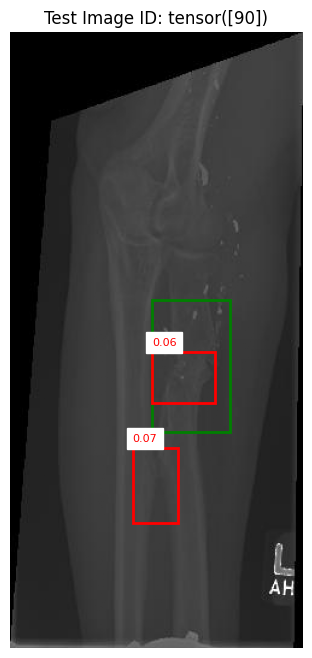

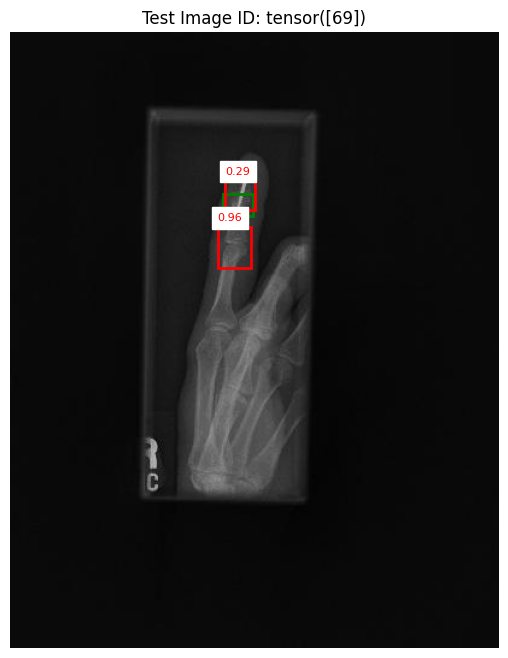

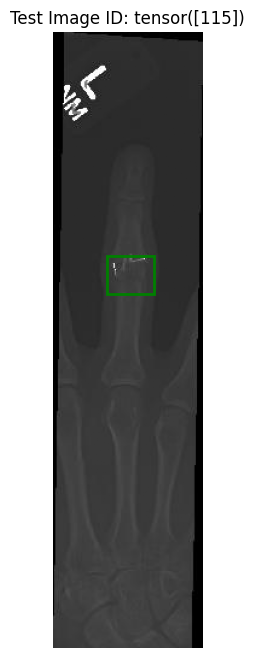

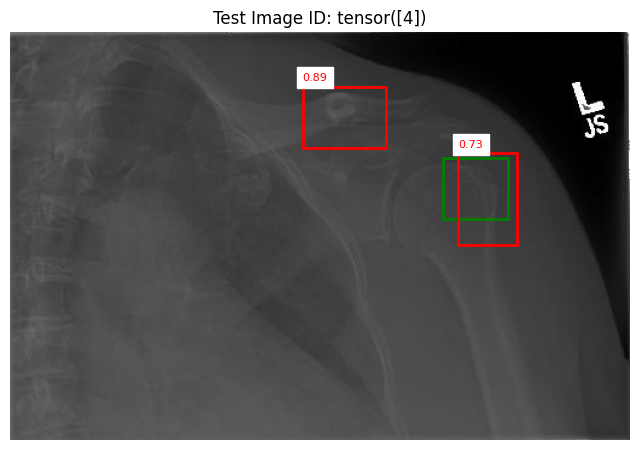

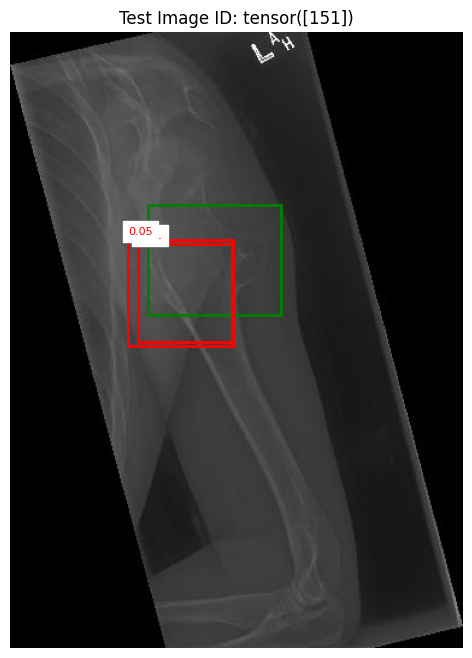

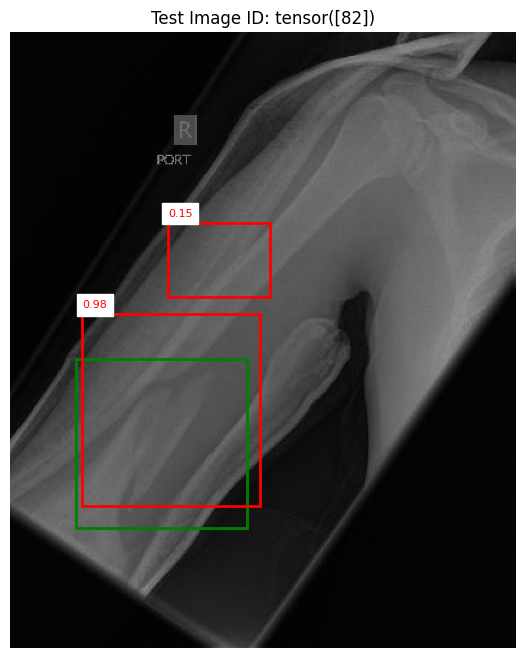

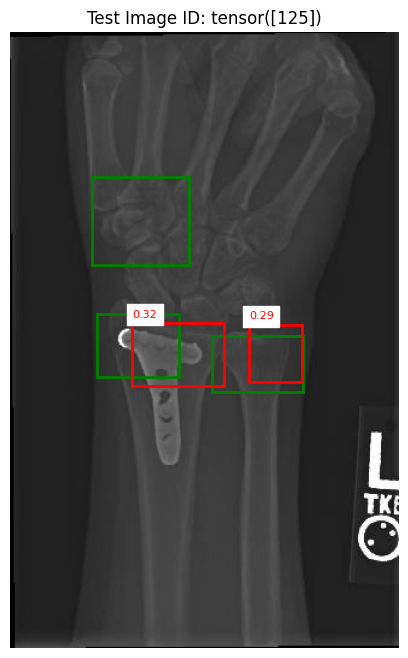

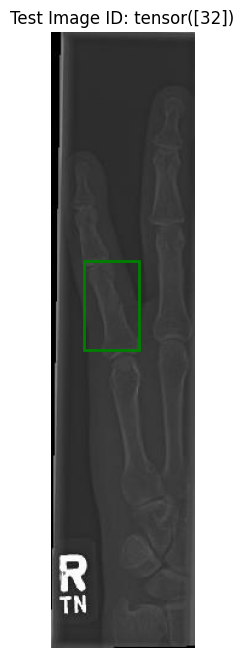

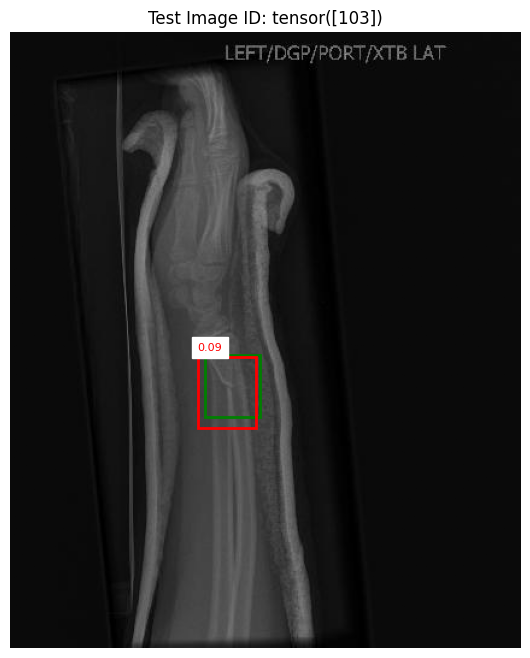

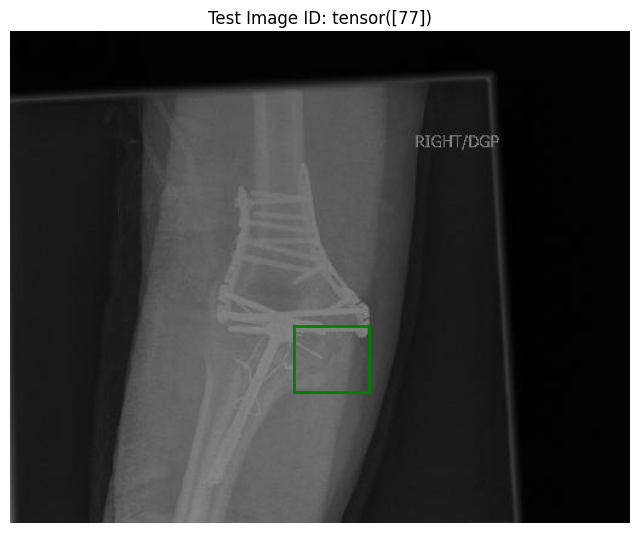

In [18]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch

# 🎯 Select 10 random samples from the test dataset for quick qualitative checks
num_samples = 10
indices = random.sample(range(len(test_dataset)), num_samples)

model.eval()  # 🔒 set model to evaluation mode (disables dropout, uses eval behavior)

with torch.no_grad():  # ⛔ disable gradient computation for inference (saves memory & time)
    for idx in indices:
        # 🖼 Get image and ground-truth target from dataset
        img, target = test_dataset[idx]
        img_tensor = img.to(device).unsqueeze(0)  # ➕ add batch dim: model expects a list or batch

        # 📦 Run inference; model returns a list of dicts (one per input image)
        output = model(img_tensor)[0]

        # 🖼 Convert image tensor to HxWxC numpy for matplotlib (move to CPU if needed)
        img_np = img.permute(1, 2, 0).cpu().numpy()

        fig, ax = plt.subplots(1, figsize=(8, 8))
        ax.imshow(img_np)

        # --- 🟩 Draw ground-truth boxes (green)
        # Ensure we handle cases where target may be empty or missing 'boxes'
        if "boxes" in target and target["boxes"].numel() > 0:
            for box in target["boxes"].cpu():
                x_min, y_min, x_max, y_max = box.tolist()
                w, h = x_max - x_min, y_max - y_min
                rect = patches.Rectangle((x_min, y_min), w, h,
                                         linewidth=2, edgecolor="g", facecolor="none")
                ax.add_patch(rect)

        # --- 🟥 Draw predicted boxes (red) with confidence scores
        # Filter low-confidence detections to reduce clutter
        for box, score in zip(output["boxes"].cpu(), output["scores"].cpu()):
            if score < 0.05:                      # 🔉 skip very low confidence detections
                continue
            x_min, y_min, x_max, y_max = box.tolist()
            w, h = x_max - x_min, y_max - y_min
            rect = patches.Rectangle((x_min, y_min), w, h,
                                     linewidth=2, edgecolor="r", facecolor="none")
            ax.add_patch(rect)
            # 📎 annotate with score (you can also show predicted class by using output["labels"])
            ax.text(x_min, y_min - 5, f"{score:.2f}",
                    color='red', fontsize=8, backgroundcolor='white')

        ax.set_title(f"Test Image ID: {target.get('image_id', idx)}")
        plt.axis('off')
        plt.show()


In [21]:
!pip install zipfile

ERROR: Could not find a version that satisfies the requirement zipfile (from versions: none)
ERROR: No matching distribution found for zipfile


In [22]:
# =============================
# ✅ IMPORTS
# =============================
import os
import json
import zipfile
import torch

# =============================
# ✅ CONFIGURATION
# =============================
SAVE_DIR = "/kaggle/working/fasterrcnn_model"
os.makedirs(SAVE_DIR, exist_ok=True)

# Make sure these exist in the notebook before running:
# model, NUM_CLASSES, EPOCHS, BATCH_SIZE, class_names, val_loader, device

# =============================
# ✅ 1. SAVE MODEL AND WEIGHTS
# =============================
model_path = os.path.join(SAVE_DIR, "model_weights.pth")
torch.save(model.state_dict(), model_path)

config = {
    "num_classes": NUM_CLASSES,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "class_names": class_names,
    "backbone": "mobilenet_v3_large_fpn",
}
with open(os.path.join(SAVE_DIR, "config.json"), "w") as f:
    json.dump(config, f, indent=2)

print(f"✅ Model and config saved in {SAVE_DIR}")

# =============================
# ✅ 2. EVALUATE METRICS
# =============================
model.eval()
total_samples = 0
correct_detections = 0
threshold = 0.5

with torch.no_grad():
    for imgs, targets in val_loader:
        imgs = [img.to(device) for img in imgs]
        outputs = model(imgs)
        for out, tgt in zip(outputs, targets):
            gt_boxes = tgt["boxes"].cpu()
            pred_boxes = out["boxes"].cpu()
            pred_scores = out["scores"].cpu()

            preds = pred_boxes[pred_scores > threshold]
            if len(preds) == 0 or len(gt_boxes) == 0:
                continue

            def iou(boxA, boxB):
                xA = max(boxA[0], boxB[0])
                yA = max(boxA[1], boxB[1])
                xB = min(boxA[2], boxB[2])
                yB = min(boxA[3], boxB[3])
                inter = max(0, xB - xA) * max(0, yB - yA)
                union = ((boxA[2]-boxA[0])*(boxA[3]-boxA[1])) + ((boxB[2]-boxB[0])*(boxB[3]-boxB[1])) - inter
                return inter / union if union > 0 else 0

            matches = 0
            for gt in gt_boxes:
                for pred in preds:
                    if iou(gt.tolist(), pred.tolist()) > 0.5:
                        matches += 1
                        break

            total_samples += len(gt_boxes)
            correct_detections += matches

accuracy = correct_detections / max(1, total_samples)
print(f"\n✅ Detection Accuracy (IoU>0.5): {accuracy*100:.2f}%")

# =============================
# ✅ 3. ZIP MODEL + CONFIG
# =============================
zip_path = "/kaggle/working/bone_xray_model.zip"
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk(SAVE_DIR):
        for file in files:
            filepath = os.path.join(root, file)
            arcname = os.path.relpath(filepath, SAVE_DIR)
            zipf.write(filepath, arcname)

print(f"✅ Model package created successfully at: {zip_path}")

✅ Model and config saved in /kaggle/working/fasterrcnn_model

✅ Detection Accuracy (IoU>0.5): 50.54%
✅ Model package created successfully at: /kaggle/working/bone_xray_model.zip


In [ ]:
model.load_state_dict(torch.load("model_weights.pth"))
model.eval()